In [18]:
import os
from pathlib import Path

current_path = Path.cwd()
if str(current_path.name) == 'examples':
    os.chdir(current_path.parent)
print(Path.cwd())

/hkfs/home/haicore/hgf_hmgu/hgf_sfs7789/git/group-cl


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from groupcl.models import mixing
from groupcl.models import encoder
from groupcl.models import dynamics
from groupcl.models import groups
from groupcl import criterions
from groupcl import solver as solvers
from groupcl import datasets
from groupcl import loader
from groupcl.experiments import Experiment
from groupcl.utils import temperature_scheduler as scheduler
from groupcl.utils import rotation_matrix as rotation_sampler

## Create and Visualize Rotation Dataset

We'll create a dataset with a few different rotation groups and visualize how points are transformed under these rotations.

In [20]:
obs_dim = 50
dynamics_dim = 3
content_dim = 3
latent_dim = dynamics_dim+ content_dim

num_mixing_layers = 3

num_samples = 1_000_000
num_group_actions = 1000
num_classes = 100

# seeds
content_seed = 46994
dynamics_seed = 33482
mixing_seed = 97228
dataset_seed = 81645

# GL(n)
generalized_linear_dynamics = dynamics.LinearDynamicsModel(
    seed=dynamics_seed,
    dim=dynamics_dim,
    num_systems=num_group_actions,
    initializer=dynamics.InvertibleMatrixLDSParameters(
            min_determinant=0.2,
            max_determinant=10.0,
            identity_threshold=1e-3,
            max_attempts=10_000,
        ),
)
# O(n)
orthogonal_dynamics = dynamics.LinearDynamicsModel(
    dim=latent_dim - content_dim,
    num_systems=num_group_actions,
    initializer=dynamics.OrthogonalMatrixLDSParameters())

# SO(n)
special_orthogonal_dynamics = dynamics.LinearDynamicsModel(
    dim=latent_dim - content_dim,
    num_systems=num_group_actions,
    initializer=dynamics.SpecialOrthogonalMatrixLDSParameters()
)


content_embedding = datasets.HypersphereContentEmbedding(
    num_classes=num_classes,
    dim=content_dim,
    seed=content_seed,
)

dataset = datasets.SyntheticContentDataset(
    num_samples=num_samples,
    content_embedding=content_embedding,
    mixing_model=mixing.NonlinearLinearMixingModel(
        output_dim=obs_dim,
        input_dim=latent_dim,
        n_layers=num_mixing_layers,
    ),
    dynamics_model=generalized_linear_dynamics,
    # dynamics_model=orthogonal_dynamics,
)

Could not loadSyntheticContentDataset from data/SyntheticContentDataset/830444526415cd41f71c9517506cc5d7: [Errno 2] No such file or directory: 'data/SyntheticContentDataset/830444526415cd41f71c9517506cc5d7/data.pt'
Could not load SyntheticContentDataset from disk, acquiring data...


In [21]:
gt_data = dataset.ground_truth_data
gt_data.shape

{'index': torch.Size([1000000]),
 'observed': {'x': torch.Size([1000000, 50]),
  'x_prime': torch.Size([1000000, 50]),
  'indices': torch.Size([1000000]),
  'actions_idx': torch.Size([1000000]),
  'class_idx': torch.Size([1000000])},
 'latents': {'x': torch.Size([1000000, 6]),
  'x_prime': torch.Size([1000000, 6]),
  'indices': torch.Size([1000000]),
  'actions_idx': torch.Size([1000000]),
  'class_idx': torch.Size([1000000])},
 'actions_idx': torch.Size([1000000]),
 'class_idx': torch.Size([1000000]),
 'auxilary': {}}

In [22]:
gt_data.latents.actions_idx.device

device(type='cuda', index=0)

In [23]:
unique_actions = torch.unique(gt_data.latents.actions_idx)

# downsample to 10 unique actions
unique_actions_to_plot = unique_actions[:10]

plot_actions_mask = (gt_data.latents.actions_idx == unique_actions_to_plot.unsqueeze(1)).any(dim=0)
plot_actions_mask = plot_actions_mask.to(gt_data.latents.actions_idx.device)
gt_data = gt_data.to(gt_data.latents.actions_idx.device)
plot_gt_data = gt_data[plot_actions_mask]
plot_gt_data.shape


{'index': torch.Size([10000]),
 'observed': {'x': torch.Size([10000, 50]),
  'x_prime': torch.Size([10000, 50]),
  'indices': torch.Size([10000]),
  'actions_idx': torch.Size([10000]),
  'class_idx': torch.Size([10000])},
 'latents': {'x': torch.Size([10000, 6]),
  'x_prime': torch.Size([10000, 6]),
  'indices': torch.Size([10000]),
  'actions_idx': torch.Size([10000]),
  'class_idx': torch.Size([10000])},
 'actions_idx': torch.Size([10000]),
 'class_idx': torch.Size([10000]),
 'auxilary': {}}

/scratch/slurm_tmpdir/job_1588947/ipykernel_3755849/2889664706.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(colormap)(np.linspace(0, 1, len(unique_actions)))


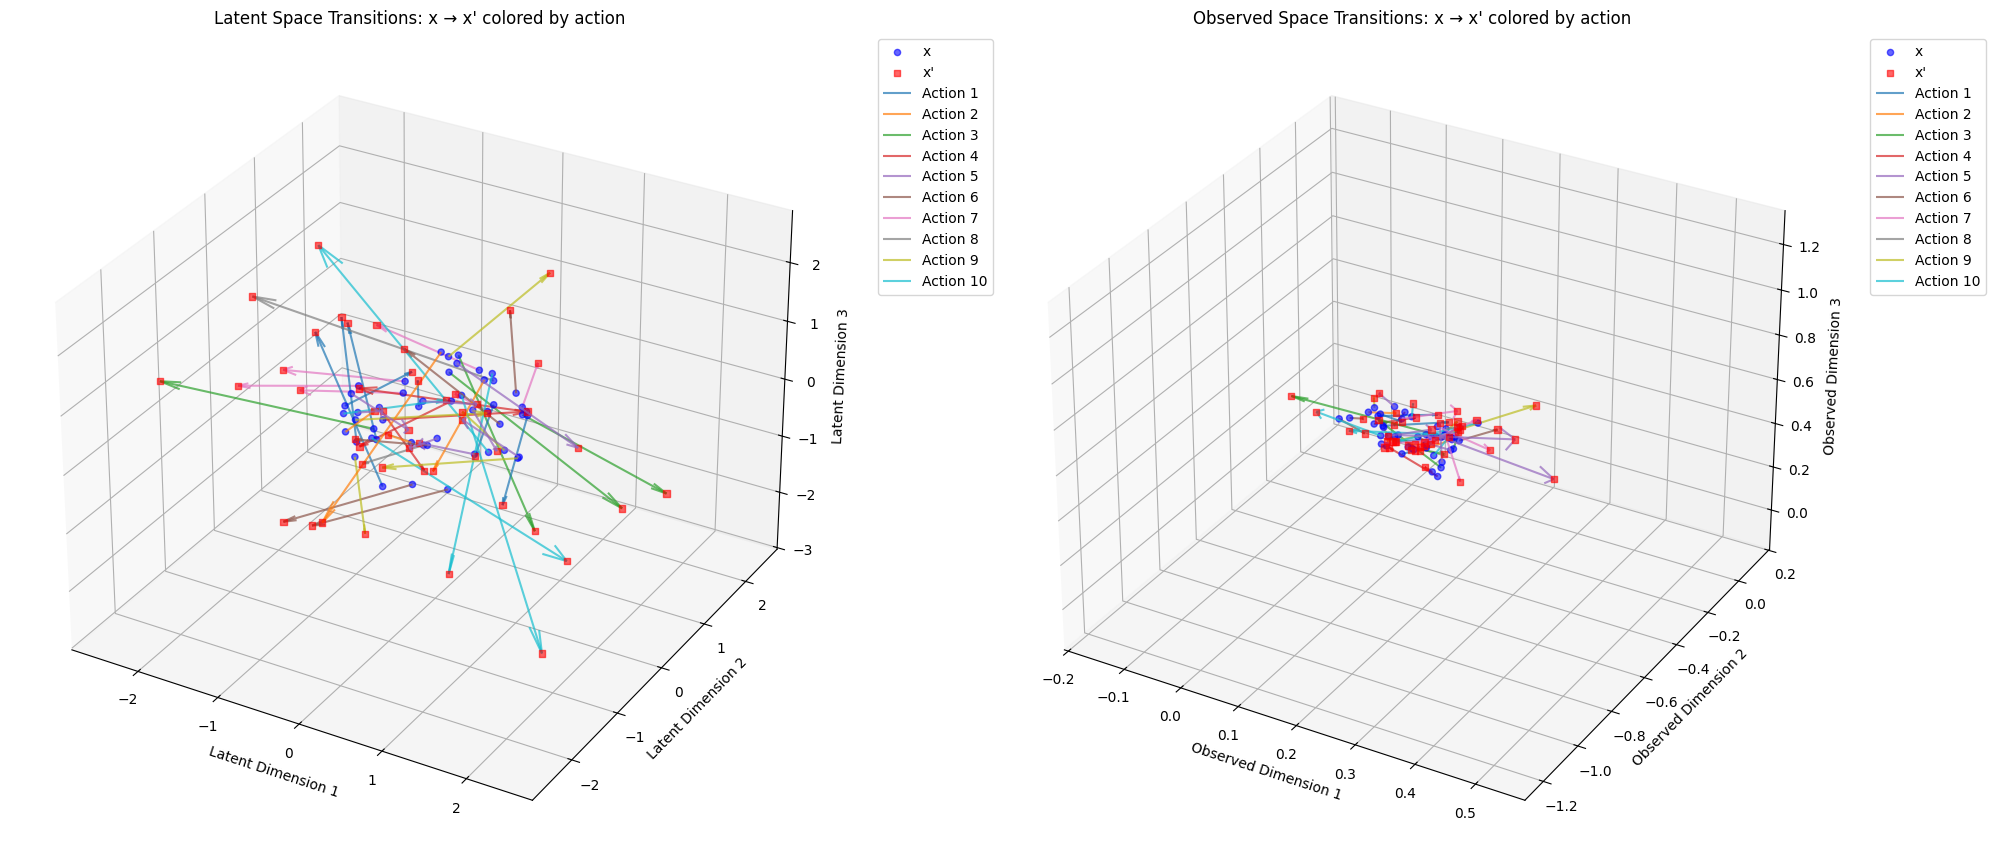

/scratch/slurm_tmpdir/job_1588947/ipykernel_3755849/2889664706.py:221: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(unique_actions)))


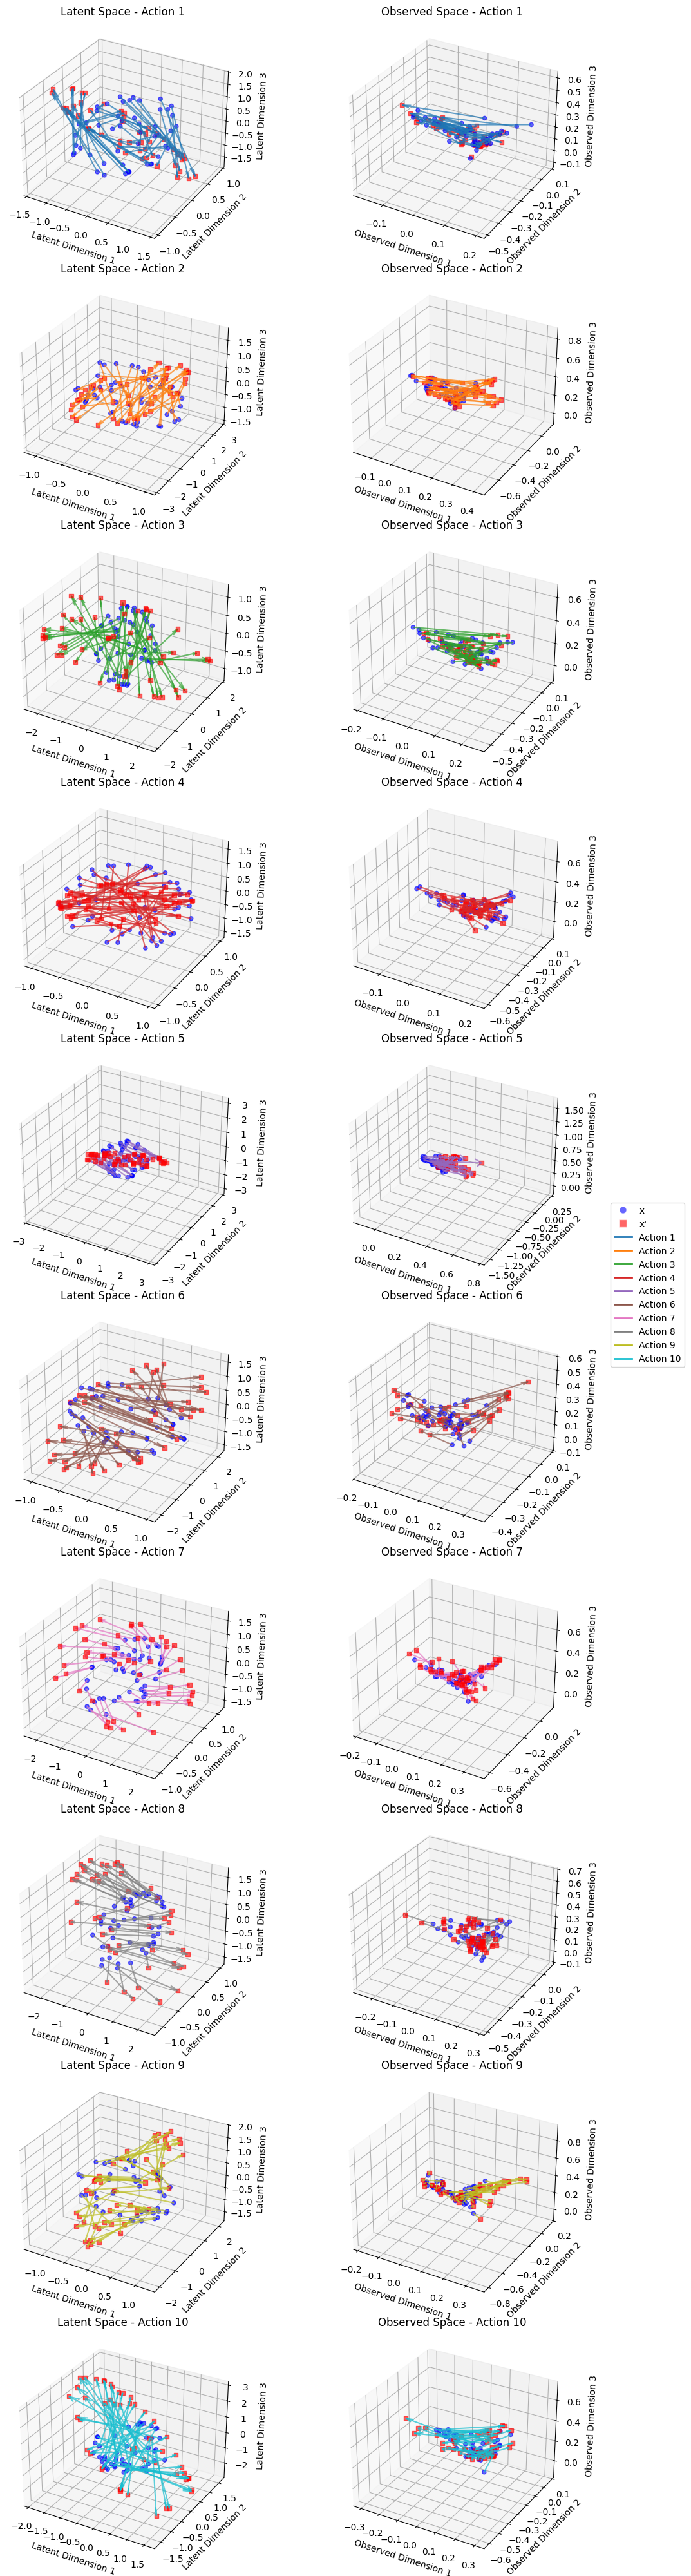

In [24]:
def plot_transitions_3d(ax, x, x_prime, actions_idx, 
                       downsample=50, seed=42, 
                       x_color='blue', x_prime_color='red',
                       x_alpha=0.6, x_prime_alpha=0.6,
                       x_size=20, x_prime_size=20,
                       x_marker='o', x_prime_marker='s',
                       quiver_alpha=0.7, arrow_length_ratio=0.1,
                       linewidth=1.5, colormap='tab10',
                       xlabel='Dimension 1', ylabel='Dimension 2', zlabel='Dimension 3',
                       title='3D Transitions: x → x\' colored by action',
                       show_legend=True):
    """
    Plot 3D transitions between x and x_prime colored by actions.
    
    Parameters:
    -----------
    ax : matplotlib 3D axis
        The axis to plot on
    x : torch.Tensor
        Starting points tensor
    x_prime : torch.Tensor  
        End points tensor
    actions_idx : torch.Tensor
        Action indices for coloring
    downsample : int
        Number of samples to show for visualization
    seed : int
        Random seed for reproducible downsampling
    x_color, x_prime_color : str
        Colors for x and x_prime scatter points
    x_alpha, x_prime_alpha : float
        Alpha values for scatter points
    x_size, x_prime_size : int
        Sizes for scatter points
    x_marker, x_prime_marker : str
        Marker styles for scatter points
    quiver_alpha : float
        Alpha for quiver arrows
    arrow_length_ratio : float
        Arrow head length ratio
    linewidth : float
        Line width for arrows
    colormap : str
        Colormap name for actions
    xlabel, ylabel, zlabel : str
        Axis labels
    title : str
        Plot title
    show_legend : bool
        Whether to show legend
    """
    import numpy as np
    
    # Convert tensors to numpy for plotting
    x_np = x.detach().cpu().numpy()
    x_prime_np = x_prime.detach().cpu().numpy()
    actions_np = actions_idx.detach().cpu().numpy()
    
    # Downsample for visualization
    np.random.seed(seed)
    total_samples = len(x_np)
    if total_samples > downsample:
        downsample_indices = np.random.choice(total_samples, downsample, replace=False)
        x_downsampled = x_np[downsample_indices]
        x_prime_downsampled = x_prime_np[downsample_indices]
        actions_downsampled = actions_np[downsample_indices]
    else:
        x_downsampled = x_np
        x_prime_downsampled = x_prime_np
        actions_downsampled = actions_np

    # For visualization, we'll plot the first 3 dimensions
    x_3d = x_downsampled[:, :3]
    x_prime_3d = x_prime_downsampled[:, :3]

    # Create a colormap for the actions
    unique_actions = np.unique(actions_downsampled)
    colors = plt.cm.get_cmap(colormap)(np.linspace(0, 1, len(unique_actions)))
    action_to_color = {action: colors[i] for i, action in enumerate(unique_actions)}

    # Plot scatter points for x and x_prime
    ax.scatter(x_3d[:, 0], x_3d[:, 1], x_3d[:, 2], 
              c=x_color, alpha=x_alpha, s=x_size, label='x', marker=x_marker)
    ax.scatter(x_prime_3d[:, 0], x_prime_3d[:, 1], x_prime_3d[:, 2], 
              c=x_prime_color, alpha=x_prime_alpha, s=x_prime_size, label="x'", marker=x_prime_marker)

    # Plot quivers colored by action
    for action in unique_actions:
        mask = actions_downsampled == action
        if np.sum(mask) > 0:
            ax.quiver(
                x_3d[mask, 0], x_3d[mask, 1], x_3d[mask, 2],
                x_prime_3d[mask, 0] - x_3d[mask, 0], 
                x_prime_3d[mask, 1] - x_3d[mask, 1], 
                x_prime_3d[mask, 2] - x_3d[mask, 2],
                color=action_to_color[action],
                alpha=quiver_alpha,
                label=f'Action {action+1}',
                arrow_length_ratio=arrow_length_ratio,
                linewidth=linewidth,
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    
    if show_legend:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


def plot_single_action_3d(ax, x, x_prime, actions_idx, target_action,
                         action_color, downsample=50, seed=42,
                         x_color='blue', x_prime_color='red',
                         x_alpha=0.6, x_prime_alpha=0.6,
                         x_size=20, x_prime_size=20,
                         x_marker='o', x_prime_marker='s',
                         quiver_alpha=0.7, arrow_length_ratio=0.1,
                         linewidth=1.5,
                         xlabel='Dimension 1', ylabel='Dimension 2', zlabel='Dimension 3',
                         title='3D Transitions'):
    """
    Plot 3D transitions for a single action.
    """
    import numpy as np
    
    # Convert tensors to numpy for plotting
    x_np = x.detach().cpu().numpy()
    x_prime_np = x_prime.detach().cpu().numpy()
    actions_np = actions_idx.detach().cpu().numpy()
    
    # Filter for target action
    action_mask = actions_np == target_action
    x_filtered = x_np[action_mask]
    x_prime_filtered = x_prime_np[action_mask]
    
    if len(x_filtered) == 0:
        ax.text(0.5, 0.5, 0.5, f'No data for Action {target_action+1}', 
                transform=ax.transAxes, ha='center', va='center')
        return
    
    # Downsample for visualization
    np.random.seed(seed)
    total_samples = len(x_filtered)
    if total_samples > downsample:
        downsample_indices = np.random.choice(total_samples, downsample, replace=False)
        x_downsampled = x_filtered[downsample_indices]
        x_prime_downsampled = x_prime_filtered[downsample_indices]
    else:
        x_downsampled = x_filtered
        x_prime_downsampled = x_prime_filtered

    # For visualization, we'll plot the first 3 dimensions
    x_3d = x_downsampled[:, :3]
    x_prime_3d = x_prime_downsampled[:, :3]

    # Plot scatter points for x and x_prime
    ax.scatter(x_3d[:, 0], x_3d[:, 1], x_3d[:, 2], 
              c=x_color, alpha=x_alpha, s=x_size, label='x', marker=x_marker)
    ax.scatter(x_prime_3d[:, 0], x_prime_3d[:, 1], x_prime_3d[:, 2], 
              c=x_prime_color, alpha=x_prime_alpha, s=x_prime_size, label="x'", marker=x_prime_marker)

    # Plot quivers with action color
    ax.quiver(
        x_3d[:, 0], x_3d[:, 1], x_3d[:, 2],
        x_prime_3d[:, 0] - x_3d[:, 0], 
        x_prime_3d[:, 1] - x_3d[:, 1], 
        x_prime_3d[:, 2] - x_3d[:, 2],
        color=action_color,
        alpha=quiver_alpha,
        label=f'Action {target_action+1}',
        arrow_length_ratio=arrow_length_ratio,
        linewidth=linewidth,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)


# Create figure with two subplots
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))

# Subplot 1: Latent space
ax1 = fig.add_subplot(121, projection='3d')
plot_transitions_3d(
    ax1, 
    plot_gt_data.latents.x, 
    plot_gt_data.latents.x_prime, 
    plot_gt_data.latents.actions_idx,
    title='Latent Space Transitions: x → x\' colored by action',
    xlabel='Latent Dimension 1',
    ylabel='Latent Dimension 2', 
    zlabel='Latent Dimension 3'
)

# Subplot 2: Observed space  
ax2 = fig.add_subplot(122, projection='3d')
plot_transitions_3d(
    ax2,
    plot_gt_data.observed.x,
    plot_gt_data.observed.x_prime,
    plot_gt_data.observed.actions_idx,
    title='Observed Space Transitions: x → x\' colored by action',
    xlabel='Observed Dimension 1',
    ylabel='Observed Dimension 2',
    zlabel='Observed Dimension 3'
)

plt.tight_layout()
plt.show()

# Create second figure with individual subplots for each action
import numpy as np

# Get unique actions and create consistent colormap
unique_actions = torch.unique(plot_gt_data.latents.actions_idx).detach().cpu().numpy()
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(unique_actions)))
action_to_color = {action: colors[i] for i, action in enumerate(unique_actions)}

# Create figure with subplots for each action
num_actions = len(unique_actions)
fig2 = plt.figure(figsize=(12, 4 * num_actions))

# Create handles for shared legend
legend_handles = []
legend_labels = []

for i, action in enumerate(unique_actions):
    # Latent space subplot
    ax_latent = fig2.add_subplot(num_actions, 2, 2*i + 1, projection='3d')
    plot_single_action_3d(
        ax_latent,
        plot_gt_data.latents.x,
        plot_gt_data.latents.x_prime,
        plot_gt_data.latents.actions_idx,
        action,
        action_color=action_to_color[action],
        title=f'Latent Space - Action {action+1}',
        xlabel='Latent Dimension 1',
        ylabel='Latent Dimension 2',
        zlabel='Latent Dimension 3'
    )
    
    # Observed space subplot
    ax_observed = fig2.add_subplot(num_actions, 2, 2*i + 2, projection='3d')
    plot_single_action_3d(
        ax_observed,
        plot_gt_data.observed.x,
        plot_gt_data.observed.x_prime,
        plot_gt_data.observed.actions_idx,
        action,
        action_color=action_to_color[action],
        title=f'Observed Space - Action {action+1}',
        xlabel='Observed Dimension 1',
        ylabel='Observed Dimension 2',
        zlabel='Observed Dimension 3'
    )
    
    # Collect legend handles only once
    if i == 0:
        # Create legend handles for x, x', and action
        from matplotlib.lines import Line2D
        legend_handles.extend([
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                   markersize=8, alpha=0.6, label='x'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='red', 
                   markersize=8, alpha=0.6, label="x'")
        ])
        legend_labels.extend(['x', "x'"])
    
    # Add action to legend
    legend_handles.append(
        Line2D([0], [0], color=action_to_color[action], linewidth=2, 
               label=f'Action {action+1}')
    )
    legend_labels.append(f'Action {action+1}')

# Add shared legend
fig2.legend(legend_handles, legend_labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()


In [25]:
dataset.latent_dim

6

# Train Equivariance by Contrast Model

In [29]:
solver_seed = 12
num_epochs = 20
batch_size = 2**10
batch_size_neg = 2**14
samples_per_action = 12
negative_distribution = "both"

dynamics_dim = dataset.dynamics_model.dim
model_latent_dim = dataset.latent_dim

loss = criterions.SymmetricGCLLoss(
    group_model=groups.GroupDynamicsModel(
        system_solver=groups.LeastSquaresSolver(orthogonal_solution=False),
        dynamics_dim=dynamics_dim,
        no_grad_solve=True,
    ),
    criterion=criterions.MseInfoNCE(
        temperature=1.0,
        infonce_type="infonce_full_denominator",
    ),
)

model = encoder.MLP(
    input_dim=dataset.observed_dim,
    output_dim=model_latent_dim,
    hidden_dim=128,
    num_layers=3,
    normalize=False,
)

solver = solvers.GCLSolver(
    seed=solver_seed,
    silence_metric_errors=True,
    num_epochs=num_epochs,
    optimizer=solvers.optim.AdamOptimizer(learning_rate=1e-3,),
    model=model,
    loss=loss,
)

train_loader=loader.InfiniteGCLDataLoader(
        num_iterations=1_000,
        shuffle=True,
        batch_size=batch_size,
        batch_size_neg=batch_size_neg,
        samples_per_action=samples_per_action,
        negative_distribution=negative_distribution,
        drop_last=True,
    )
val_loader=loader.GCLDataLoader(
    shuffle=False,
    batch_size=batch_size,
    batch_size_neg=batch_size,
    samples_per_action=samples_per_action,
    negative_distribution=negative_distribution,
)
exp = Experiment(
    dataset=dataset,
    solver=solver,
    dataset_split=datasets.splits.OODSystemsSplit(
        train_ratio=0.8,
        test_ratio=0.1,
    ),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=val_loader,
)

Effective train ratio: 0.8 (desired: 0.8)
Effective val ratio: 0.099 (desired: 0.09999999999999995)
Effective test ratio: 0.101 (desired: 0.1)
Loaded SyntheticContentDataset from disk
Loaded SyntheticContentDataset from disk
Loaded SyntheticContentDataset from disk


In [30]:
from groupcl.metrics.identifiability import R2, VanillaR2

In [31]:
exp.run(
    eval_frequency=1000,
    disable_jaxtyping=True,
    eval_kwargs=dict(metrics=[
         R2(group="x", true_subspace="group", bias=False, hold_out_split=True,),
         VanillaR2(group="x_prime_pred_emb",
              true_subspace="group",
              pred_subspace="group"),
    ]),
)

Training on device: cuda
Training with random seed: 12


Training:   0%|          | 0/20000 [00:00<?, ?iter/s]

Computing metric R2_X_t[group]_p[all]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]


VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric R2_X_t[group]_p[all]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]
VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric R2_X_t[group]_p[all]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]
VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric R2_X_t[group]_p[all]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]
VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric R2_X_t[group]_p[all]_hold_out

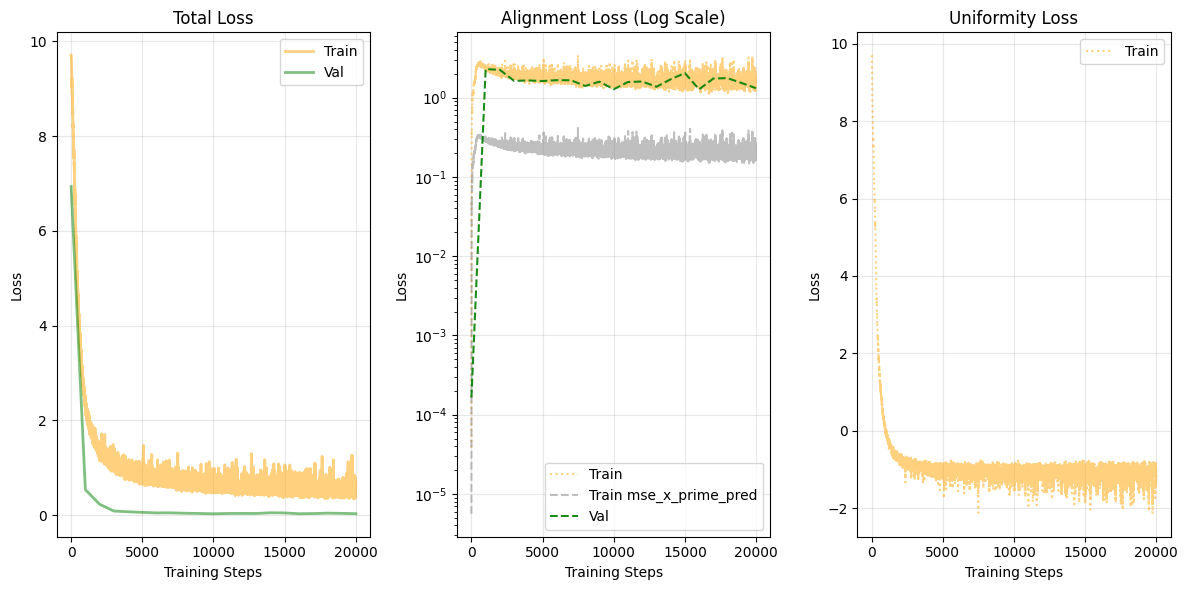

In [32]:
import matplotlib.pyplot as plt

# Configuration variables for styling
FIGSIZE = (12, 6)
TRAIN_COLOR = 'orange'
VAL_COLOR = 'green'
ALPHA_MAIN = 0.5
ALPHA_VAL = 0.9
LINE_STYLES = {
    'x': ':',
    'y': '--',
    'overall': '-',
}
LINE_WIDTH_OVERALL = 2
GRID_ALPHA = 0.3
USE_LOG_SCALE = True  # Option to use log scale for y-axis

# Create a figure with 3 subplots for different loss types
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, sharey=False)
train_steps = range(len(exp.solver.logs.get('train_loss_total', [])))
val_steps = exp.solver.logs.get('val_step', [])

# Define plot configurations for each subplot
subplot_configs = [
    # Subplot 1: Total Loss
    {
        'ax_idx':
            0,
        'title':
            'Total Loss',
        'log_scale':
            False,  # Normal scale for total loss
        'traces': [
            {
                'key': 'train_loss',
                'color': TRAIN_COLOR,
                'style': LINE_STYLES['overall'],
                'label': 'Train',
                'alpha': ALPHA_MAIN,
                'linewidth': LINE_WIDTH_OVERALL
            },
            {
                'key': 'val_loss',
                'color': VAL_COLOR,
                'style': LINE_STYLES['overall'],
                'label': 'Val',
                'alpha': ALPHA_MAIN,
                'linewidth': LINE_WIDTH_OVERALL,
                'x_data': 'val_step'
            },
        ]
    },
    # Subplot 2: Alignment Loss
    {
        'ax_idx':
            1,
        'title':
            'Alignment Loss',
        'log_scale':
            True,  # Use log scale for alignment loss
        'traces': [
            {
                'key': 'train_loss_align',
                'color': TRAIN_COLOR,
                'style': LINE_STYLES['x'],
                'label': 'Train',
                'alpha': ALPHA_MAIN
            },
            {
                'key': 'train_mse_x_prime_pred',
                'color': "gray",
                'style': LINE_STYLES['y'],
                'label': 'Train mse_x_prime_pred',
                'alpha': ALPHA_MAIN
            },
            {
                'key': 'val_loss_align',
                'color': VAL_COLOR,
                'style': LINE_STYLES['y'],
                'label': 'Val',
                'alpha': ALPHA_VAL,
                'x_data': 'val_step'
            },
            {
                'key': 'val_mse_x_prime_pred',
                'color': VAL_COLOR,
                'style': LINE_STYLES['x'],
                'label': 'Val MSE X',
                'alpha': ALPHA_VAL
            },
        ]
    },
    # Subplot 3: Uniformity Loss
    {
        'ax_idx':
            2,
        'title':
            'Uniformity Loss',
        'log_scale':
            False,  # Normal scale for uniformity loss
        'traces': [
            {
                'key': 'train_loss_uniformity',
                'color': TRAIN_COLOR,
                'style': LINE_STYLES['x'],
                'label': 'Train',
                'alpha': ALPHA_MAIN
            },
            {
                'key': 'val_loss_uniformity',
                'color': VAL_COLOR,
                'style': LINE_STYLES['x'],
                'label': 'Val',
                'alpha': ALPHA_MAIN
            },
        ]
    }
]

# Generate each subplot
for config in subplot_configs:
    ax = axes[config['ax_idx']]

    # Add each trace if the key exists in logs
    for trace in config['traces']:
        if trace['key'] in exp.solver.logs:
            # Get the data
            y_data = exp.solver.logs[trace['key']]

            # Check if data is empty
            if len(y_data) == 0:
                print(f"Warning: {trace['key']} has no data")
                continue

            # Determine x data (train_steps or val_steps)
            x_data = val_steps if trace.get(
                'x_data') == 'val_step' else train_steps

            # Make sure x and y have the same length
            if len(x_data) != len(y_data):
                print(
                    f"Warning: {trace['key']} has different lengths for x ({len(x_data)}) and y ({len(y_data)})"
                )
                continue

            # Plot with specified parameters
            plot_kwargs = {
                'color': trace['color'],
                'linestyle': trace['style'],
                'label': trace['label'],
                'alpha': trace['alpha']
            }

            # Add optional linewidth if specified
            if 'linewidth' in trace:
                plot_kwargs['linewidth'] = trace['linewidth']

            ax.plot(x_data, y_data, **plot_kwargs)
        else:
            print(f"Warning: {trace['key']} not found in logs")

    # Set labels and styling
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Loss')
    ax.set_title(config['title'])
    ax.legend()
    ax.grid(True, alpha=GRID_ALPHA)

    # Apply log scale if specified for this subplot
    if USE_LOG_SCALE and config.get('log_scale', False):
        ax.set_yscale('log')
        ax.set_title(f"{config['title']} (Log Scale)")

plt.tight_layout()
plt.show()

In [33]:
from groupcl.metrics.dynamics import LogisticRegressionClassification, NNActionAccuracy, NNActionPrediction
from groupcl.metrics.identifiability import CCA, R2, GroupHomomorphismR2, VanillaR2


val_metrics = [
    R2(
        group="x",
        true_subspace="group",
        pred_subspace="group",
        bias=False,
        hold_out_split=True,
        fitting_method="lsqt",
    ),
    VanillaR2(
        group="x_prime_pred_emb",
        true_subspace="group",
        pred_subspace="group",
    ),
    LogisticRegressionClassification(group="x"),
    NNActionAccuracy(k=1, batch_size=8, max_samples=20_000),
]




In [34]:
# train_results = exp.evaluate_train(metrics=val_metrics)
val_results = exp.evaluate_val(metrics=val_metrics)
test_results = exp.evaluate_test(metrics=val_metrics)

Computing metric R2_X_t[group]_p[group]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]
VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric LogisticRegressionClassification_x


/home/hgf_hmgu/hgf_sfs7789/miniconda3/envs/groupcl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Computing metric NNActionAccuracy_top_1_n_20000


/home/hgf_hmgu/hgf_sfs7789/miniconda3/envs/groupcl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:01<00:00, 1461.35it/s]


Computing metric R2_X_t[group]_p[group]_hold_out_Backward
Computing metric VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]
VanillaR2: True slice translated to true_subspace_slice: slice(0, 3, None)
VanillaR2: True slice translated to pred_subspace_slice: slice(0, 3, None)
Computing metric LogisticRegressionClassification_x


/home/hgf_hmgu/hgf_sfs7789/miniconda3/envs/groupcl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Computing metric NNActionAccuracy_top_1_n_20000


/home/hgf_hmgu/hgf_sfs7789/miniconda3/envs/groupcl/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:01<00:00, 1487.92it/s]


In [35]:
metric_name_map = {
    "R²(x)": 'R2_X_t[group]_p[group]_hold_out_Backward',
    "R²(G)": 'VanillaR2_X_PRIME_PRED_EMB_t[group]_p[group]',
    "Acc(C)": 'LogisticRegressionClassification_x',
    "Acc(G, 1)": 'NNActionAccuracy_top_1_n_20000',
}

# Pretty print validation results
print("Validation Results:")
for pretty_name, metric_key in metric_name_map.items():
    if metric_key in val_results:
        print(f"  {pretty_name}: {val_results[metric_key]:.4f}")
    else:
        print(f"  {pretty_name}: Not found")

print("\nTest Results:")
for pretty_name, metric_key in metric_name_map.items():
    if metric_key in test_results:
        print(f"  {pretty_name}: {test_results[metric_key]:.4f}")
    else:
        print(f"  {pretty_name}: Not found")


Validation Results:
  R²(x): 0.9983
  R²(G): 0.9966
  Acc(C): 0.9770
  Acc(G, 1): 0.9526

Test Results:
  R²(x): 0.9983
  R²(G): 0.9965
  Acc(C): 0.9770
  Acc(G, 1): 0.9499


In [36]:
val_gt_data = exp.val_loader.ground_truth_data
val_gt_data.shape

{'index': torch.Size([101000]),
 'observed': {'x': torch.Size([101000, 50]),
  'x_prime': torch.Size([101000, 50]),
  'indices': torch.Size([101000]),
  'actions_idx': torch.Size([101000]),
  'class_idx': torch.Size([101000])},
 'latents': {'x': torch.Size([101000, 6]),
  'x_prime': torch.Size([101000, 6]),
  'indices': torch.Size([101000]),
  'actions_idx': torch.Size([101000]),
  'class_idx': torch.Size([101000])},
 'actions_idx': torch.Size([101000]),
 'class_idx': torch.Size([101000]),
 'auxilary': {}}

In [46]:
with torch.no_grad():
    val_preds = exp.solver.predictions(exp.val_loader)
val_preds.shape

{'embeddings': {'x': torch.Size([101000, 6]),
  'x_prime': torch.Size([101000, 6]),
  'indices': torch.Size([101000]),
  'actions_idx': torch.Size([101000]),
  'class_idx': torch.Size([101000])},
 'dynamics': {'x_prime': torch.Size([101000, 6]),
  'Qx': torch.Size([101000, 6, 6])}}

In [53]:
# Align embeddings to gt latents
from sklearn.linear_model import LinearRegression

emb_x_np = val_preds.embeddings.x.cpu().numpy()
emb_x_prime_np = val_preds.embeddings.x_prime.cpu().numpy()
gt_latents_x_np = val_gt_data.latents.x.cpu().numpy()
gt_latents_x_prime_np = val_gt_data.latents.x_prime.cpu().numpy()
lr_model = LinearRegression()
lr_model.fit(emb_x_np, gt_latents_x_np)
aligned_x = lr_model.predict(emb_x_np)
aligned_x_prime = lr_model.predict(emb_x_prime_np)

from sklearn.metrics import r2_score
print(f"R²(x) : {r2_score(gt_latents_x_np, aligned_x):.4f}")
print(f"R²(x') : {r2_score(gt_latents_x_prime_np, aligned_x_prime):.4f}")


R²(x) : 0.9927
R²(x') : 0.9908


/scratch/slurm_tmpdir/job_1588947/ipykernel_3755849/477295829.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(unique_actions)))


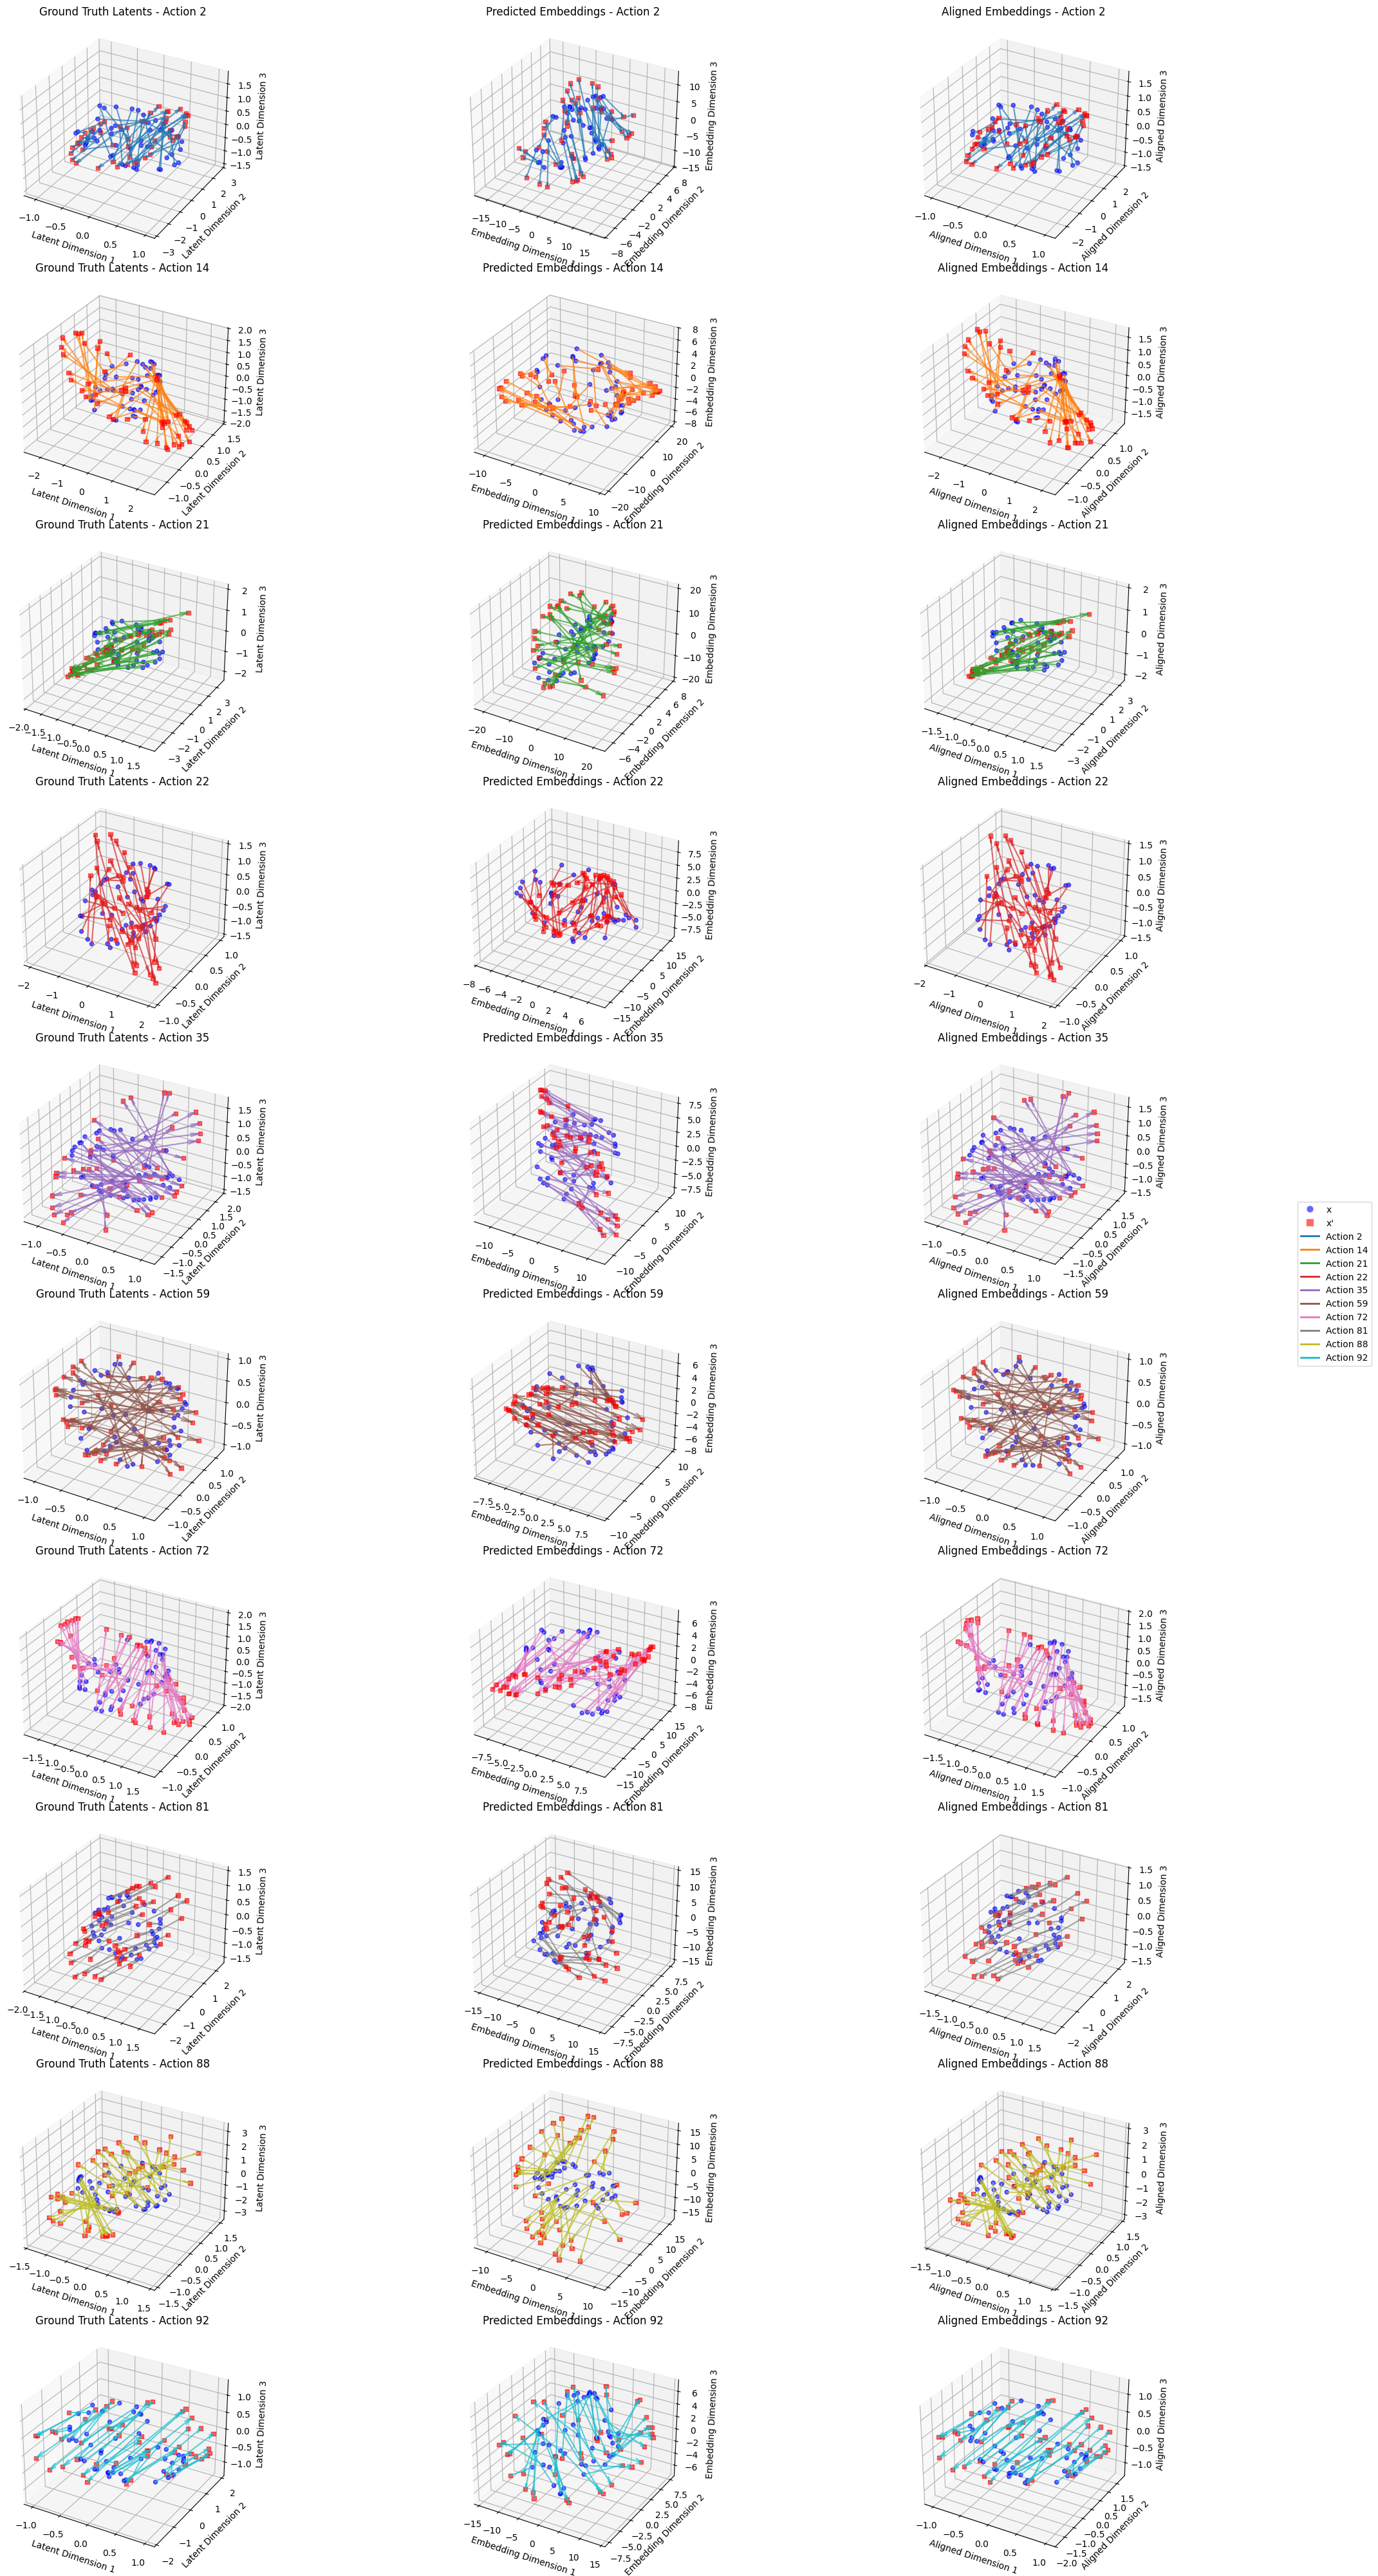

In [ ]:
# Extract predicted embeddings
pred_x = val_preds.embeddings.x
pred_x_prime = val_preds.embeddings.x_prime

# Convert aligned embeddings back to tensors for plotting
aligned_x_tensor = torch.tensor(aligned_x, dtype=torch.float32)
aligned_x_prime_tensor = torch.tensor(aligned_x_prime, dtype=torch.float32)

# Create comparison figure with individual subplots for each action
import numpy as np

# Get unique actions and create consistent colormap
unique_actions = torch.unique(val_gt_data.latents.actions_idx).detach().cpu().numpy()
# Downsample to maximum 10 actions
unique_actions = unique_actions[:10]
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(unique_actions)))
action_to_color = {action: colors[i] for i, action in enumerate(unique_actions)}

# Create figure with subplots for each action (GT vs Predicted vs Aligned)
num_actions = len(unique_actions)
fig = plt.figure(figsize=(24, 4 * num_actions))

# Create handles for shared legend
legend_handles = []
legend_labels = []

for i, action in enumerate(unique_actions):
    # Ground Truth latent space subplot
    ax_gt = fig.add_subplot(num_actions, 3, 3*i + 1, projection='3d')
    plot_single_action_3d(
        ax_gt,
        val_gt_data.latents.x,
        val_gt_data.latents.x_prime,
        val_gt_data.latents.actions_idx,
        action,
        action_color=action_to_color[action],
        title=f'Ground Truth Latents - Action {action+1}',
        xlabel='Latent Dimension 1',
        ylabel='Latent Dimension 2',
        zlabel='Latent Dimension 3',
        downsample=50  # Downsample to 50 points per subplot
    )
    
    # Predicted embeddings subplot
    ax_pred = fig.add_subplot(num_actions, 3, 3*i + 2, projection='3d')
    plot_single_action_3d(
        ax_pred,
        pred_x,
        pred_x_prime,
        val_gt_data.actions_idx,  # Use same action indices for filtering
        action,
        action_color=action_to_color[action],
        title=f'Predicted Embeddings - Action {action+1}',
        xlabel='Embedding Dimension 1',
        ylabel='Embedding Dimension 2',
        zlabel='Embedding Dimension 3',
        downsample=50  # Downsample to 50 points per subplot
    )
    
    # Aligned embeddings subplot
    ax_aligned = fig.add_subplot(num_actions, 3, 3*i + 3, projection='3d')
    plot_single_action_3d(
        ax_aligned,
        aligned_x_tensor,
        aligned_x_prime_tensor,
        val_gt_data.actions_idx,  # Use same action indices for filtering
        action,
        action_color=action_to_color[action],
        title=f'Linearly Aligned Embeddings - Action {action+1}',
        xlabel='Aligned Dimension 1',
        ylabel='Aligned Dimension 2',
        zlabel='Aligned Dimension 3',
        downsample=50  # Downsample to 50 points per subplot
    )
    
    # Collect legend handles only once
    if i == 0:
        # Create legend handles for x, x', and action
        from matplotlib.lines import Line2D
        legend_handles.extend([
            Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                   markersize=8, alpha=0.6, label='x'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='red', 
                   markersize=8, alpha=0.6, label="x'")
        ])
        legend_labels.extend(['x', "x'"])
    
    # Add action to legend
    legend_handles.append(
        Line2D([0], [0], color=action_to_color[action], linewidth=2, 
               label=f'Action {action+1}')
    )
    legend_labels.append(f'Action {action+1}')

# Add shared legend
fig.legend(legend_handles, legend_labels, loc='center right', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()
